In [53]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask

In [43]:
# sampling rate
sr = 50
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

In [44]:
# --
#T_02 = 1 # Tengo que normalizar por la cantidad de puntos (t)
f_02 = 1 #
omega_02 = 2*np.pi*f_02 #Tengo que normalizar por la cantidad de puntos (t)
cos_02 =np.cos(omega_02*t)

# --
f_03 = 2
omega_03 = 2*np.pi*f_03
cos_03 =np.cos(omega_03*t)

# --
n = 7
f_04 = n
omega_04 = 2*np.pi*f_04
cos_04 =np.cos(omega_04*t)

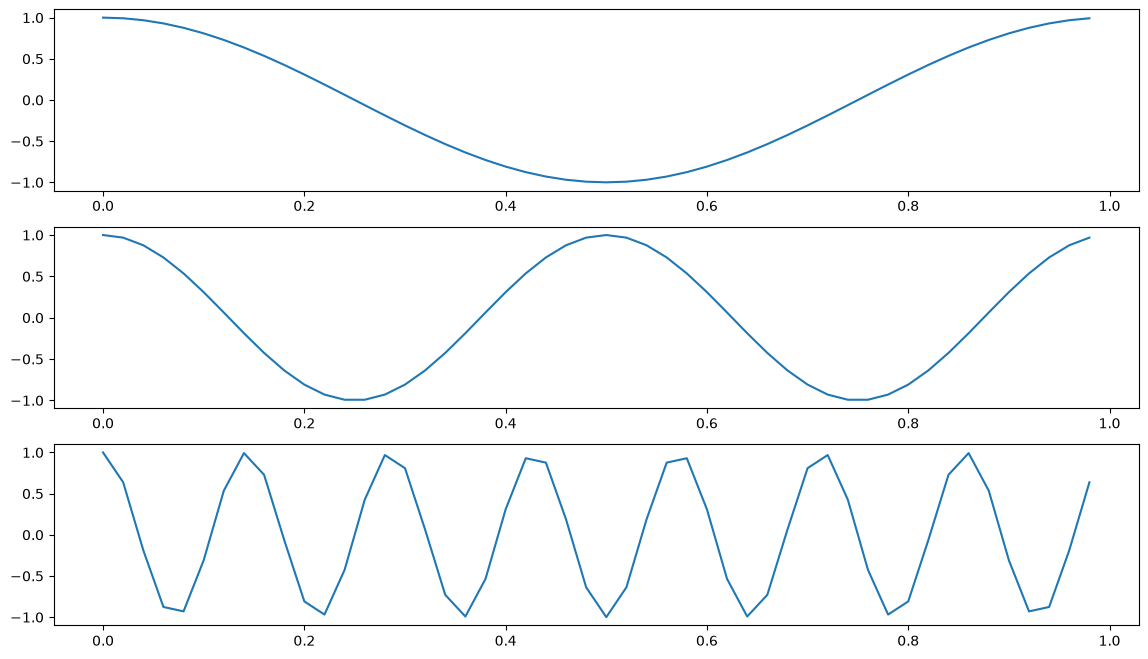

In [45]:
fig, ax = plt.subplots(3, 1, figsize=(14, 8))

ax[0].plot(t, cos_02)

ax[1].plot(t, cos_03)

ax[2].plot(t, cos_04)

In [46]:
# Suma de los cosenos
cos_sum = cos_02 + cos_03 + cos_04

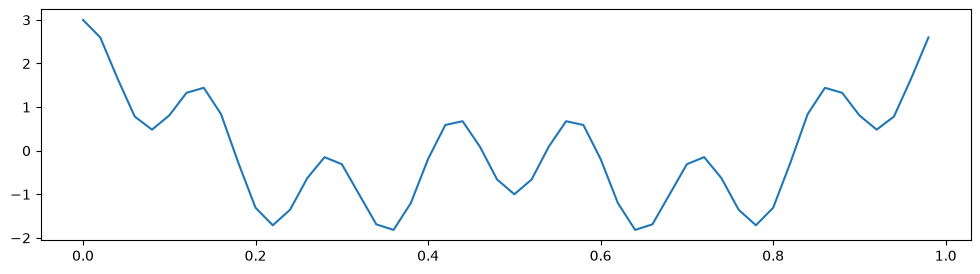

In [47]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, cos_sum)

### --

In [8]:
def DFT(x):
    """
    Function to calculate the 
    discrete Fourier Transform 
    of a 1D real-valued signal x
    """

    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(-2j * np.pi * k * n / N)
    
    X = np.dot(e, x)
    
    return X


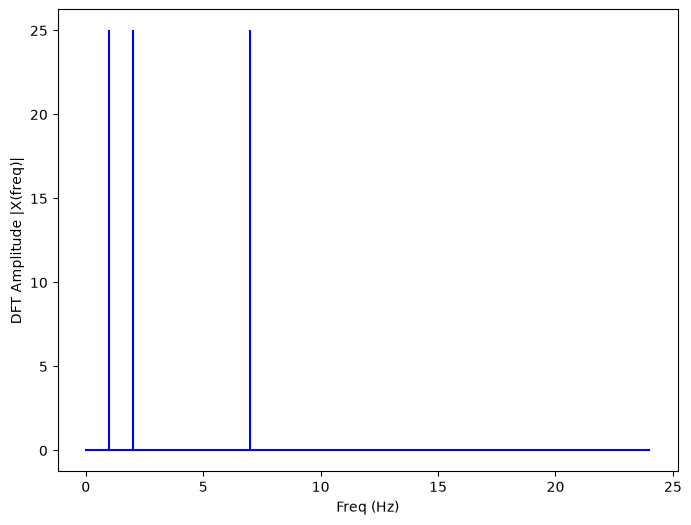

In [51]:
X = DFT(cos_sum)

# calculate the frequency
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T 

plt.figure(figsize = (8, 6))
plt.stem(freq[:sr//2], abs(X)[:sr//2], 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')
plt.show()

### ---

In [54]:
# Vector área de estudio
study_area = gpd.read_file('sierras_fields.geojson')

# Bandas L8

# Lista de paths
list_paths = ['L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B4.TIF', 'L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B5.TIF']


# Apertura, clip y guardadado de los datos de las bandas Red y NIR
list_arrays_bands = []

mask_transform = None

for p in list_paths:
    
    band_ds = rio.open(p)
    
    study_read_repj = study_area.to_crs(epsg=band_ds.crs.to_epsg())
    
    band_mask, mask_transform = mask(dataset=band_ds, shapes=study_read_repj.geometry, nodata=None, crop=True)
    
    list_arrays_bands.append((band_mask*2.75e-05)-0.02)
    
# Convierto a numpy da
array_bands_rn = np.array(list_arrays_bands)

In [55]:
# Cómputo de array de NDVI
ndvi_array = (array_bands_rn[1]-array_bands_rn[0])/(array_bands_rn[1]+array_bands_rn[0])
ndvi_array = np.where(ndvi_array <= 0, np.nan, ndvi_array)

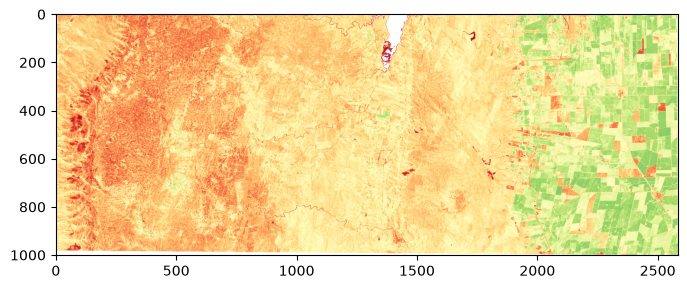

In [59]:
fig, ax = plt.subplots(figsize=(8, 3), tight_layout=True)
ax.imshow(ndvi_array[0], cmap='RdYlGn')

In [63]:
# sampling rate
sr = 12
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

In [69]:
n = 3
f_04 = n
omega_04 = 2*np.pi*f_04
cos_04 =np.cos(omega_04*t)

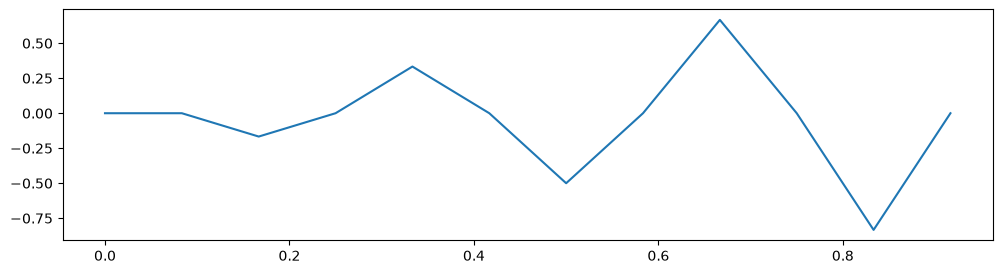

In [70]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, cos_04*t)